# Exploratory Data Analysis — Give Me Some Credit

Goal: understand the raw data before making any preprocessing / modeling decisions.
Every cleaning choice in `src/data_preprocessing.py` is justified by a finding in this notebook —
this notebook is the "why", the module is the "how".

Dataset: [Kaggle — Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit), 150,000 borrowers,
target `SeriousDlqin2yrs` = 1 if the borrower had a 90+ day delinquency within 2 years.

In [1]:
import sys
from pathlib import Path

# allow `import src...` when running the notebook from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preprocessing import (
    load_raw_data, split_train_test, DataCleaner,
    PAST_DUE_COLS, SENTINEL_CODES, WINSORIZE_COLS,
)
from src.config import RAW_TRAIN_PATH, TARGET_COL

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = load_raw_data(RAW_TRAIN_PATH)
df.shape

2026-07-09 10:10:30,535 | INFO | Loaded raw data: 150000 rows, 11 columns


(150000, 11)

## 1. Overview & target distribution

In [2]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

Default rate: 6.68%
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


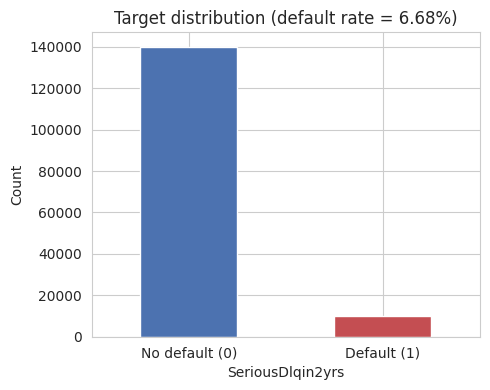

In [4]:
default_rate = df[TARGET_COL].mean()
print(f"Default rate: {default_rate:.2%}")
print(df[TARGET_COL].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
ax.set_title(f"Target distribution (default rate = {default_rate:.2%})")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Takeaway:** only 6.7% of borrowers default. This is a meaningfully imbalanced classification
problem. A trivial model that always predicts "no default" would already score ~93% accuracy while
being useless for risk decisions — this is why plain accuracy is dropped in favor of ROC-AUC / PR-AUC /
recall-focused metrics later (see `src/evaluate.py`), and why class imbalance is handled explicitly
during modeling (class weights vs. SMOTE).

## 2. Missing values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


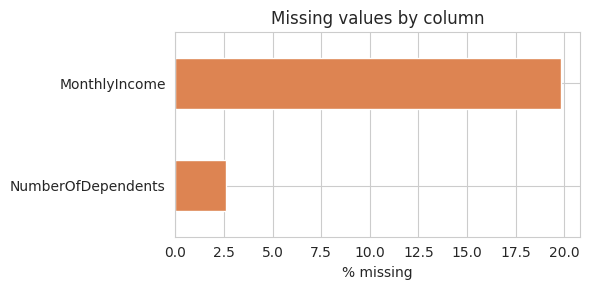

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
missing_pct.sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()

**`MonthlyIncome`** is missing for ~20% of rows, and **`NumberOfDependents`** for ~2.6%.
20% is too large to simply drop — we need to understand whether this missingness is random or
informative before deciding how to handle it.

In [7]:
income_missing = df["MonthlyIncome"].isna()

print("Rows where MonthlyIncome is missing:", income_missing.sum())
print("Of those, DebtRatio > 1:", ((income_missing) & (df["DebtRatio"] > 1)).sum(),
      f"({((income_missing) & (df['DebtRatio'] > 1)).sum() / income_missing.sum():.1%})")
print()
print("Default rate when MonthlyIncome is missing:  ", f"{df.loc[income_missing, TARGET_COL].mean():.2%}")
print("Default rate when MonthlyIncome is present:  ", f"{df.loc[~income_missing, TARGET_COL].mean():.2%}")

Rows where MonthlyIncome is missing: 29731
Of those, DebtRatio > 1: 27904 (93.9%)

Default rate when MonthlyIncome is missing:   5.61%
Default rate when MonthlyIncome is present:   6.95%


**Finding:** ~94% of rows with missing `MonthlyIncome` have `DebtRatio > 1` — i.e. "monthly debt
payments exceed monthly income", which is a plausible but unusually high share. This strongly suggests
`DebtRatio` may represent a different quantity (e.g. an absolute debt figure rather than a true ratio)
in exactly the rows where income wasn't captured — the missingness is **not random (MCAR)**, it correlates
with a specific data-collection pattern. The default rate for this group is also different from the rest.

**Decision:** impute `MonthlyIncome` with the training median, but also add a binary
`monthly_income_missing` flag so the model can still use the fact that income *wasn't reported* as a
feature in its own right, rather than just silently filling the gap.

In [8]:
dep_missing = df["NumberOfDependents"].isna()
print("Default rate when NumberOfDependents is missing:", f"{df.loc[dep_missing, TARGET_COL].mean():.2%}")
print("Default rate when NumberOfDependents is present:", f"{df.loc[~dep_missing, TARGET_COL].mean():.2%}")
print()
print(df["NumberOfDependents"].value_counts(dropna=False).sort_index())

Default rate when NumberOfDependents is missing: 4.56%
Default rate when NumberOfDependents is present: 6.74%

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
NaN      3924
Name: count, dtype: int64


No comparably strong signal for `NumberOfDependents` missingness (default rates are close, and the
column is dominated by 0). **Decision:** simple median imputation (median = 0), no flag needed — kept
proportionate to the evidence found, rather than adding a flag "just in case".

## 3. Outliers and data-quality issues

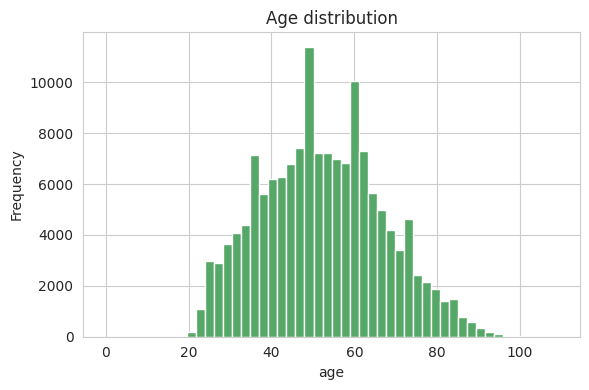

Rows with age == 0: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
df["age"].plot(kind="hist", bins=50, ax=ax, color="#55A868")
ax.set_title("Age distribution")
ax.set_xlabel("age")
plt.tight_layout()
plt.show()

print("Rows with age == 0:", (df["age"] == 0).sum())
df[df["age"] == 0]

A single row has `age == 0`, which is impossible for a borrower. With only 1 row out of 150,000
this has negligible impact either way — it's treated as missing and imputed with the training median
age, consistent with how every other missing value in this pipeline is handled (rather than a one-off
special case, which would be brittle if a similar value appeared in new client data at inference time).

In [10]:
for col in PAST_DUE_COLS:
    print(f"\n{col} — top values:")
    print(df[col].value_counts().sort_index(ascending=False).head(6))


NumberOfTime30-59DaysPastDueNotWorse — top values:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
10      4
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse — top values:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
11      1
9       1
8       2
7       9
Name: count, dtype: int64

NumberOfTimes90DaysLate — top values:
NumberOfTimes90DaysLate
98    264
96      5
17      1
15      2
14      2
13      4
Name: count, dtype: int64


In [11]:
sentinel_mask = pd.Series(False, index=df.index)
for col in PAST_DUE_COLS:
    sentinel_mask = sentinel_mask | df[col].isin(SENTINEL_CODES)

print("Rows carrying the 96/98 code in at least one past-due column:", sentinel_mask.sum())
print()
print("Default rate in this subset:   ", f"{df.loc[sentinel_mask, TARGET_COL].mean():.2%}")
print("Default rate in the rest of the data:", f"{df.loc[~sentinel_mask, TARGET_COL].mean():.2%}")
print()
df.loc[sentinel_mask, PAST_DUE_COLS + [TARGET_COL]].head(5)

Rows carrying the 96/98 code in at least one past-due column: 269

Default rate in this subset:    54.65%
Default rate in the rest of the data: 6.60%



,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1734,98,98,98,1
2287,98,98,98,0
3885,98,98,98,0
4418,98,98,98,0
4706,98,98,98,0


**Finding — this is the most important discovery in this EDA.** The values `96` and `98` appear
together across all three "past due" columns for the exact same ~269 rows. Being late 96–98 times is not
plausible for any real borrower — this is almost certainly a sentinel/error code from the original data
collection system (e.g. "unknown" or "not applicable"), not a genuine count.

Critically, this subset has a **~55% default rate vs. ~6.7% overall** — an 8x difference. If we simply
dropped these rows as "bad data", we would throw away one of the strongest signals in the entire
dataset. If we left the raw values in, `98` would badly distort both linear model coefficients and tree
split points, since it looks like an extreme numeric outlier rather than what it actually represents.

**Decision:** capture the pattern in a single binary flag `had_past_due_sentinel_code` (all three
columns move together, so one flag is enough — three near-duplicate flags would just add
multicollinearity), then replace the 96/98 values with each column's median computed *excluding* the
sentinel rows, so the model still sees a plausible-looking count for those rows while the flag carries
the actual signal.

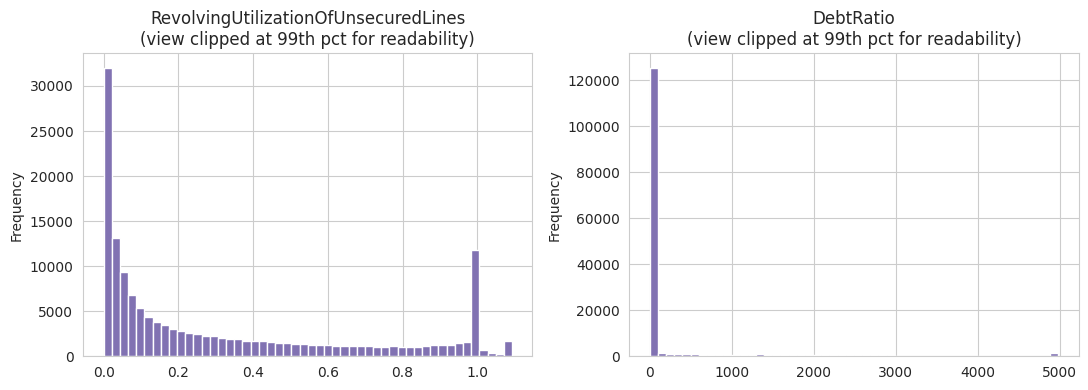

       RevolvingUtilizationOfUnsecuredLines      DebtRatio
count                         150000.000000  150000.000000
mean                               6.048438     353.005076
std                              249.755371    2037.818523
min                                0.000000       0.000000
25%                                0.029867       0.175074
50%                                0.154181       0.366508
75%                                0.559046       0.868254
max                            50708.000000  329664.000000

Quantiles:
       RevolvingUtilizationOfUnsecuredLines   DebtRatio
0.900                              0.981278    1267.000
0.950                              1.000000    2449.000
0.975                              1.000000    3489.025
0.990                              1.092956    4979.040
0.999                           1571.006000   10613.074
1.000                          50708.000000  329664.000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, WINSORIZE_COLS):
    df[col].clip(upper=df[col].quantile(0.99)).plot(kind="hist", bins=50, ax=ax, color="#8172B2")
    ax.set_title(f"{col}\n(view clipped at 99th pct for readability)")

plt.tight_layout()
plt.show()

print(df[WINSORIZE_COLS].describe())
print()
print("Quantiles:")
print(df[WINSORIZE_COLS].quantile([0.9, 0.95, 0.975, 0.99, 0.999, 1.0]))

Both `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` are meant to behave like ratios
(typically well under ~2), but both have an extreme long right tail — max values of ~50,708 and
~329,664 respectively. These are very likely data entry errors or edge-case calculations rather than
genuine values.

**Decision:** rather than pick an arbitrary domain cutoff (e.g. "cap utilization at 2"), both features
are **winsorized (capped) at the 97.5th percentile learned on the training data**. This limits the
leverage of implausible extreme values — particularly important for Logistic Regression, which is
sensitive to outliers — while leaving the vast majority of the distribution, and the relative ordering
of values, untouched. Tree-based models are naturally more robust to this, but applying the same
treatment to all models keeps the comparison between them fair (every model sees the same input data).

## 4. Correlations with the target

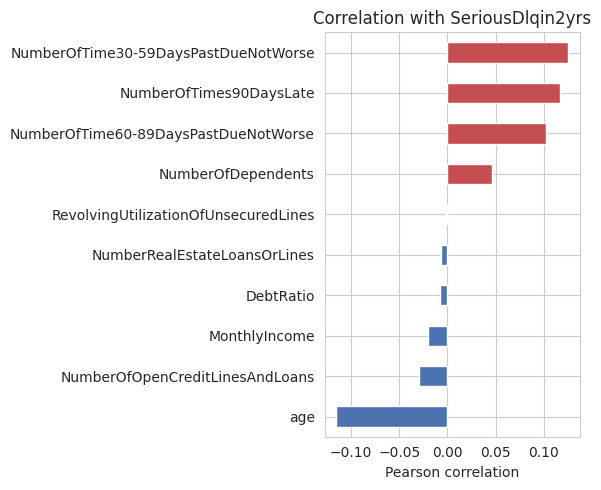

In [13]:
corr_with_target = df.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
corr_with_target.plot(kind="barh", ax=ax, color=["#C44E52" if v > 0 else "#4C72B0" for v in corr_with_target])
ax.set_title("Correlation with SeriousDlqin2yrs")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

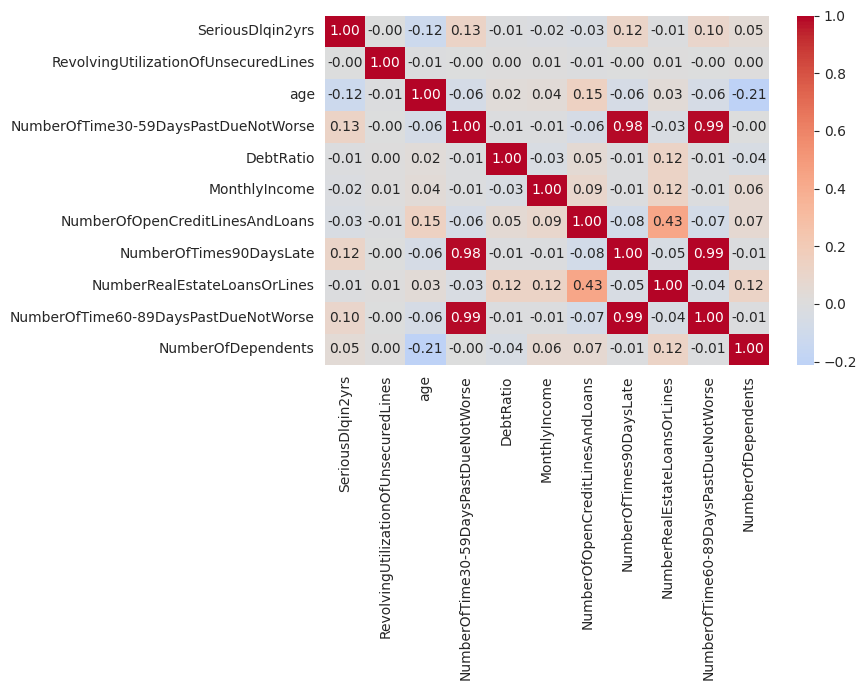

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

As expected, the three delinquency-count columns (`NumberOfTimes90DaysLate` and the 30-59 / 60-89
day variants) are the strongest positive correlates of default — consistent with the intuition that past
delinquency predicts future delinquency. `RevolvingUtilizationOfUnsecuredLines` is also strongly
positively correlated (higher utilization of available credit signals financial strain). `age` is
mildly negatively correlated (older borrowers default less often in this data). Note: linear correlation
undersells non-linear relationships and interactions, which tree-based models (Random Forest, XGBoost,
LightGBM) can pick up even where the raw Pearson correlation looks weak — this is one reason the model
comparison later isn't limited to Logistic Regression alone.

## 5. Applying the cleaning pipeline (`src/data_preprocessing.py`)

Everything above motivates the rules implemented in `DataCleaner`. Here we run the actual pipeline
code (not a re-implementation) and confirm the before/after effect on the training split.

In [15]:
train_df, test_df = split_train_test(df)

cleaner = DataCleaner()
cleaner.fit(train_df)
train_clean = cleaner.transform(train_df)

print("Missing values before cleaning:", train_df.isnull().sum().sum())
print("Missing values after cleaning: ", train_clean.isnull().sum().sum())
print()
print("Max past-due value before cleaning:",
      train_df[PAST_DUE_COLS].max().max())
print("Max past-due value after cleaning: ",
      train_clean[PAST_DUE_COLS].max().max())
print()
print("New engineered flag columns:", [c for c in train_clean.columns if c not in train_df.columns])
print()
print("had_past_due_sentinel_code value counts:")
print(train_clean["had_past_due_sentinel_code"].value_counts())

2026-07-09 10:10:32,005 | INFO | Split: train=120000 rows (default rate 6.68%), test=30000 rows (default rate 6.68%)


Missing values before cleaning: 26803
Missing values after cleaning:  0

Max past-due value before cleaning: 98
Max past-due value after cleaning:  17.0

New engineered flag columns: ['had_past_due_sentinel_code', 'monthly_income_missing']

had_past_due_sentinel_code value counts:
had_past_due_sentinel_code
0    119786
1       214
Name: count, dtype: int64


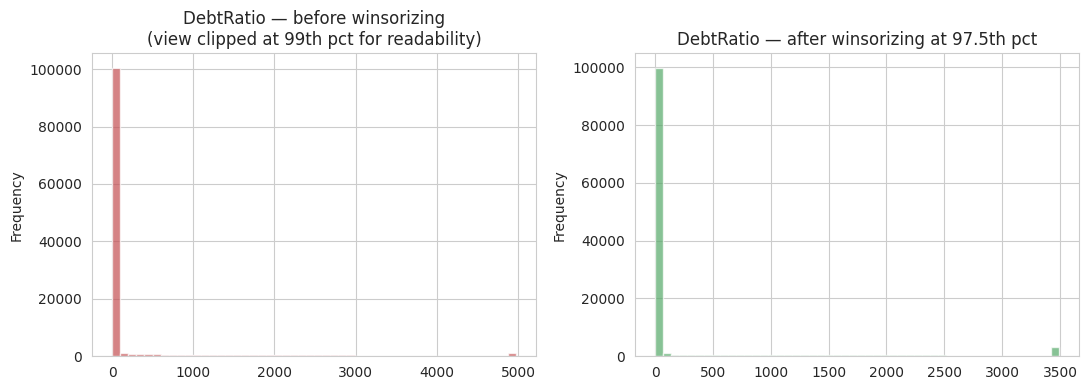

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

train_df["DebtRatio"].clip(upper=train_df["DebtRatio"].quantile(0.99)).plot(
    kind="hist", bins=50, ax=axes[0], color="#C44E52", alpha=0.7)
axes[0].set_title("DebtRatio — before winsorizing\n(view clipped at 99th pct for readability)")

train_clean["DebtRatio"].plot(kind="hist", bins=50, ax=axes[1], color="#55A868", alpha=0.7)
axes[1].set_title("DebtRatio — after winsorizing at 97.5th pct")

plt.tight_layout()
plt.show()

## Summary & next steps

Key findings that drive the rest of the project:

1. **Imbalanced target** (6.7% default) → ROC-AUC / PR-AUC / recall matter more than accuracy;
   class imbalance is handled explicitly during modeling (class weights vs. SMOTE, compared head-to-head).
2. **`age == 0`** → single impossible value, imputed like any other missing value.
3. **96/98 sentinel code** in the past-due columns → NOT noise — an 8x higher default rate in that
   subset makes this one of the most informative signals in the data. Captured via a binary flag rather
   than discarded.
4. **`MonthlyIncome` missingness is informative** (correlates with anomalous `DebtRatio` values) →
   flagged, not just silently imputed.
5. **Extreme outliers** in `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` → winsorized at a
   data-driven percentile rather than an arbitrary cutoff.

All of this is implemented as a leakage-safe, testable `DataCleaner` transformer in
`src/data_preprocessing.py` (fit on train only, unit-tested in `tests/test_data_preprocessing.py`).

**Next:** `src/feature_engineering.py` — derived ratios (e.g. debt-to-income interactions), and any
encoding/scaling needed ahead of modeling.